In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

q1 = pd.read_csv("../data/01_league_3pt_trend.csv")
print(q1.shape)
print(q1.head())

(22, 8)
   season_start_year season_label  games_played  \
0               2000      2000-01          1189   
1               2001      2001-02          1189   
2               2002      2002-03          1189   
3               2003      2003-04          1189   
4               2004      2004-05          1230   

   threes_attempted_per_team_game  threes_made_per_team_game  \
0                           13.71                       4.85   
1                           14.75                       5.22   
2                           14.68                       5.13   
3                           14.93                       5.18   
4                           15.75                       5.60   

   pct_of_shots_from_three  three_point_pct  pts_per_team_game  
0                    17.01            35.35              94.81  
1                    18.15            35.36              95.48  
2                    18.17            34.95              95.08  
3                    18.70            34

CHART 1

In [2]:
# Load all four datasets so we have them ready for the rest of the notebook
q1 = pd.read_csv("../data/01_league_3pt_trend.csv")
q2 = pd.read_csv("../data/02_3pt_leader_by_season.csv")
q3 = pd.read_csv("../data/03_volume_vs_winning.csv")
q4 = pd.read_csv("../data/04_playoffs_vs_regular.csv")

# Set a clean default style for all charts
sns.set_style("whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

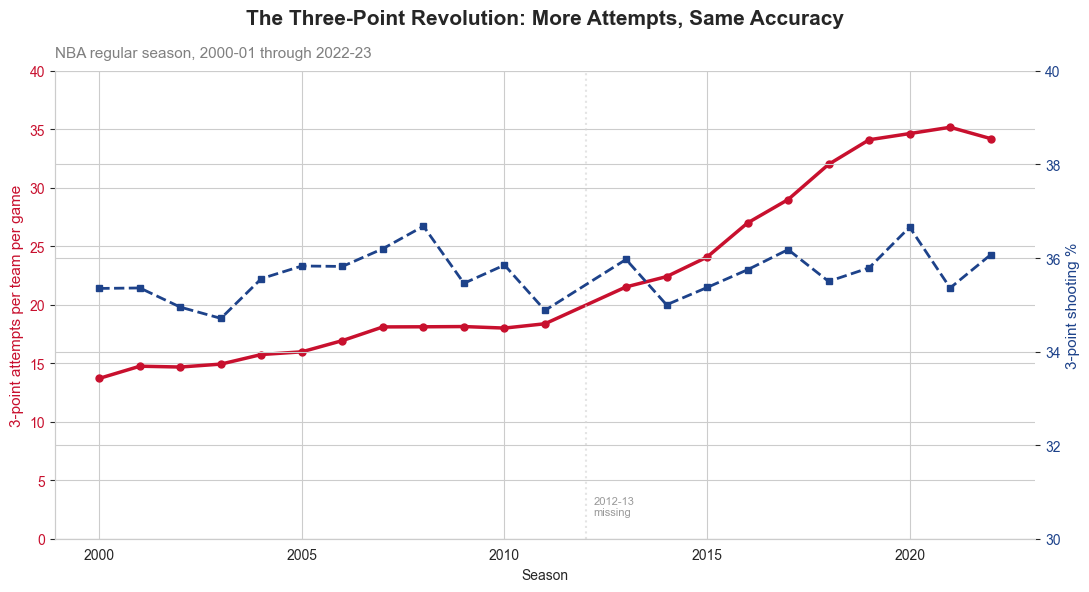

In [4]:
# Chart 1: League-wide 3-point attempts and shooting % over time
fig, ax1 = plt.subplots(figsize=(11, 6))

# Left axis: 3PA per team-game (the headline)
color_3pa = "#c8102e"  # NBA red
ax1.plot(
    q1["season_start_year"],
    q1["threes_attempted_per_team_game"],
    color=color_3pa,
    linewidth=2.5,
    marker="o",
    markersize=5,
    label="3PA per team per game"
)
ax1.set_xlabel("Season")
ax1.set_ylabel("3-point attempts per team per game", color=color_3pa, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_3pa)
ax1.set_ylim(0, 40)

# Right axis: 3-point shooting %
ax2 = ax1.twinx()
color_pct = "#1d428a"  # NBA blue
ax2.plot(
    q1["season_start_year"],
    q1["three_point_pct"],
    color=color_pct,
    linewidth=2,
    marker="s",
    markersize=4,
    linestyle="--",
    label="3-point %"
)
ax2.set_ylabel("3-point shooting %", color=color_pct, fontsize=11)
ax2.tick_params(axis="y", labelcolor=color_pct)
ax2.set_ylim(30, 40)
ax2.spines["top"].set_visible(False)

# Title and subtitle
plt.suptitle(
    "The Three-Point Revolution: More Attempts, Same Accuracy",
    fontsize=15, fontweight="bold", y=0.98
)
ax1.set_title(
    "NBA regular season, 2000-01 through 2022-23",
    fontsize=11, color="gray", pad=10, loc="left"
)

# Note the missing season
ax1.axvline(x=2012, color="lightgray", linestyle=":", alpha=0.6)
ax1.text(2012.2, 2, "2012-13\nmissing", fontsize=8, color="gray", alpha=0.8)

plt.tight_layout()
plt.savefig("../charts/01_league_3pt_trend.png", dpi=150, bbox_inches="tight")
plt.show()

CHART 2

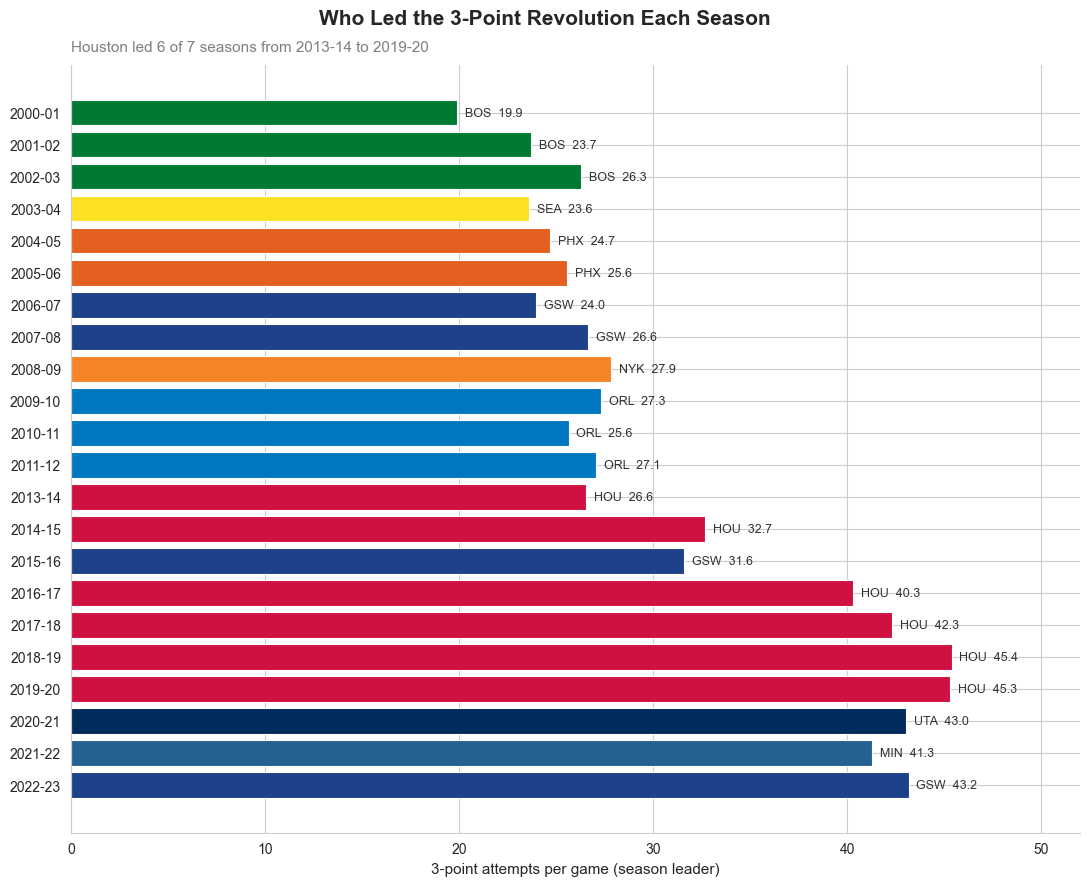

In [5]:
# Chart 2: Which team led the league in 3PA per game, by season
fig, ax = plt.subplots(figsize=(11, 9))

# Color map: distinct color per team that ever led
team_colors = {
    "BOS": "#007A33",   # Celtics green
    "SEA": "#fbe122",   # SuperSonics yellow
    "PHX": "#e56020",   # Suns orange
    "GSW": "#1d428a",   # Warriors blue
    "NYK": "#f58426",   # Knicks orange
    "ORL": "#0077c0",   # Magic blue
    "HOU": "#ce1141",   # Rockets red
    "UTA": "#002b5c",   # Jazz navy
    "MIN": "#236192",   # Wolves blue
}

# Sort top-to-bottom oldest-first
q2_sorted = q2.sort_values("season_start_year", ascending=False)
colors = [team_colors.get(team, "#888888") for team in q2_sorted["leader"]]

bars = ax.barh(
    q2_sorted["season_label"],
    q2_sorted["leader_3pa_per_game"],
    color=colors,
    edgecolor="white",
    linewidth=0.8,
)

# Annotate each bar with the team abbreviation and the value
for bar, team, value in zip(bars, q2_sorted["leader"], q2_sorted["leader_3pa_per_game"]):
    ax.text(
        bar.get_width() + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{team}  {value:.1f}",
        va="center",
        fontsize=9,
        color="#333333",
    )

ax.set_xlabel("3-point attempts per game (season leader)", fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, 52)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.suptitle(
    "Who Led the 3-Point Revolution Each Season",
    fontsize=15, fontweight="bold", y=0.98
)
ax.set_title(
    "Houston led 6 of 7 seasons from 2013-14 to 2019-20",
    fontsize=11, color="gray", pad=10, loc="left"
)

plt.tight_layout()
plt.savefig("../charts/02_3pt_leader_by_season.png", dpi=150, bbox_inches="tight")
plt.show()

Chart #3

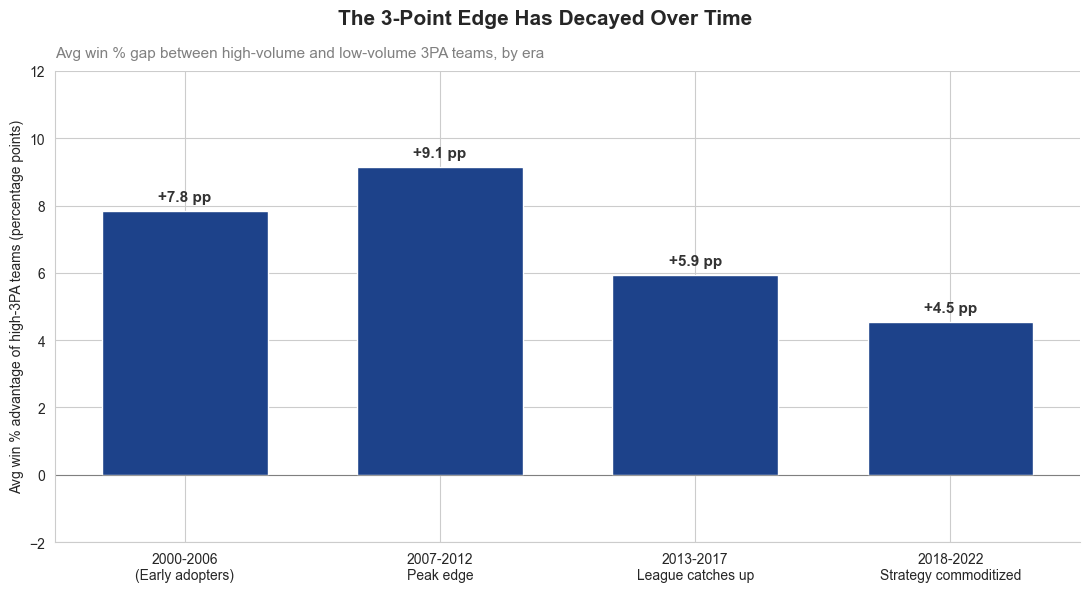

In [7]:
# Chart 3: Era-level alpha decay (replaces noisy season-by-season line)
fig, ax = plt.subplots(figsize=(11, 6))

# Bucket seasons into eras
def assign_era(year):
    if year <= 2006:
        return "2000-2006\n(Early adopters)"
    elif year <= 2012:
        return "2007-2012\nPeak edge"
    elif year <= 2017:
        return "2013-2017\nLeague catches up"
    else:
        return "2018-2022\nStrategy commoditized"

q3_era = q3.copy()
q3_era["era"] = q3_era["season_start_year"].apply(assign_era)

era_summary = q3_era.groupby("era", sort=False)["win_pct_gap"].mean().reset_index()

# Color: blue when advantage exists, red when it's gone
colors = ["#1d428a" if gap >= 3 else "#3a6db8" if gap >= 0 else "#c8102e" for gap in era_summary["win_pct_gap"]]

bars = ax.bar(
    era_summary["era"],
    era_summary["win_pct_gap"],
    color=colors,
    edgecolor="white",
    linewidth=1,
    width=0.65,
)

# Value labels above each bar
for bar, value in zip(bars, era_summary["win_pct_gap"]):
    label_y = value + 0.3 if value >= 0 else value - 0.6
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        label_y,
        f"+{value:.1f} pp" if value >= 0 else f"{value:.1f} pp",
        ha="center",
        fontsize=11,
        fontweight="bold",
        color="#333333",
    )

ax.axhline(y=0, color="#333333", linestyle="-", linewidth=0.8, alpha=0.5)
ax.set_ylabel("Avg win % advantage of high-3PA teams (percentage points)")
ax.set_xlabel("")
ax.set_ylim(-2, 12)

# Strip the right and top spines (the rcParams default already does this, but just in case)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.suptitle(
    "The 3-Point Edge Has Decayed Over Time",
    fontsize=15, fontweight="bold", y=0.98
)
ax.set_title(
    "Avg win % gap between high-volume and low-volume 3PA teams, by era",
    fontsize=11, color="gray", pad=10, loc="left"
)

plt.tight_layout()
plt.savefig("../charts/03_volume_vs_winning.png", dpi=150, bbox_inches="tight")
plt.show()

Chart #4

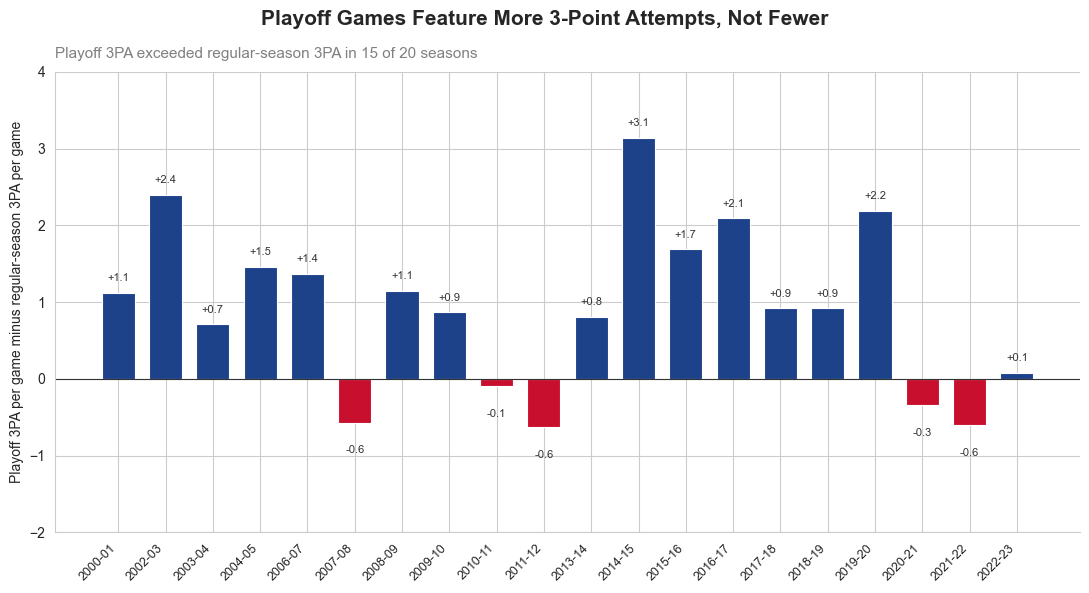

In [9]:
# Chart 4: Per-season gap between playoff and regular-season 3PA
fig, ax = plt.subplots(figsize=(11, 6))

q4_sorted = q4.sort_values("season_start_year")

# Color each bar by direction
colors = ["#1d428a" if gap >= 0 else "#c8102e" for gap in q4_sorted["playoff_minus_reg_3pa"]]

bars = ax.bar(
    q4_sorted["season_label"],
    q4_sorted["playoff_minus_reg_3pa"],
    color=colors,
    edgecolor="white",
    linewidth=0.8,
    width=0.7,
)

# Zero reference line
ax.axhline(y=0, color="#333333", linewidth=0.8)

# Value labels above/below each bar
for bar, value in zip(bars, q4_sorted["playoff_minus_reg_3pa"]):
    label_y = value + 0.15 if value >= 0 else value - 0.4
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        label_y,
        f"+{value:.1f}" if value >= 0 else f"{value:.1f}",
        ha="center",
        fontsize=8,
        color="#333333",
    )

ax.set_xlabel("")
ax.set_ylabel("Playoff 3PA per game minus regular-season 3PA per game")
ax.set_ylim(-2, 4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xticks(rotation=45, ha="right", fontsize=9)

# Count and report
positive_count = (q4_sorted["playoff_minus_reg_3pa"] >= 0).sum()
total_count = len(q4_sorted)

plt.suptitle(
    "Playoff Games Feature More 3-Point Attempts, Not Fewer",
    fontsize=15, fontweight="bold", y=0.98
)
ax.set_title(
    f"Playoff 3PA exceeded regular-season 3PA in {positive_count} of {total_count} seasons",
    fontsize=11, color="gray", pad=10, loc="left"
)

plt.tight_layout()
plt.savefig("../charts/04_playoffs_vs_regular.png", dpi=150, bbox_inches="tight")
plt.show()

